<a href="https://colab.research.google.com/github/Shakir5665/Mini-project---Waste-Sorting-System/blob/main/Mini_project_Implementation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving dataset_Implementation-2.zip to dataset_Implementation-2.zip


In [ ]:
import zipfile

zip_ref = zipfile.ZipFile("dataset_Implementation-2.zip", 'r')
zip_ref.extractall("/content")
zip_ref.close()

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
train_path = "/content/dataset_Implementation-2/Train"
val_path = "/content/dataset_Implementation-2/Validation"
test_path = "/content/dataset_Implementation-2/Test"

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

validation_data = val_gen.flow_from_directory(
    val_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4462 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Found 1680 images belonging to 2 classes.


In [ ]:
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=20,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 191ms/step - accuracy: 0.8498 - loss: 0.3528 - val_accuracy: 0.8500 - val_loss: 0.3278
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 161ms/step - accuracy: 0.8805 - loss: 0.2758 - val_accuracy: 0.9067 - val_loss: 0.2192
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 152ms/step - accuracy: 0.8901 - loss: 0.2672 - val_accuracy: 0.8622 - val_loss: 0.2805
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step - accuracy: 0.8889 - loss: 0.2657 - val_accuracy: 0.8856 - val_loss: 0.2455
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step - accuracy: 0.9087 - loss: 0.2123 - val_accuracy: 0.9089 - val_loss: 0.2151
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step - accuracy: 0.8957 - loss: 0.2657 - val_accuracy: 0.9078 - val_loss: 0.2018
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step - accuracy: 0.9188 - loss: 0.2225 - val_accuracy: 0.9144 - val_loss: 0.1942
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step - accuracy: 0.9102 - loss: 0

In [ ]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9284 - loss: 0.2053
Test Accuracy: 0.9595237970352173


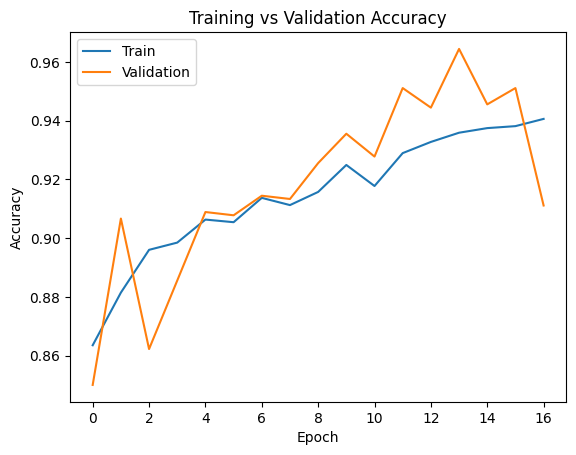

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
predictions = model.predict(test_data)

predicted_classes = np.round(predictions)

cm = confusion_matrix(test_data.classes, predicted_classes)

print(cm)

53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step
[[ 115   23]
 [  45 1497]]


In [ ]:
print(classification_report(
    test_data.classes,
    predicted_classes
))

              precision    recall  f1-score   support

           0       0.72      0.83      0.77       138
           1       0.98      0.97      0.98      1542

    accuracy                           0.96      1680
   macro avg       0.85      0.90      0.87      1680
weighted avg       0.96      0.96      0.96      1680



In [ ]:
model.save("waste_classification_model_v2.h5")

In [ ]:
files.download("waste_classification_model_v2.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
Hello